## Let's simulate OptimAc on the data collected by the survey

### Data import and formating into participant lists

In [23]:
import pandas as pan
from participant_real import Participant

dfs = [f0,f1]  = [pan.read_csv("../data/experimental2/filtered/f0.csv"), pan.read_csv("../data/experimental2/filtered/f1.csv")]
f1

,n,action_name,motivation,feedback
0,1,weekly,2,Oui
1,1,monthly,2,Oui
2,1,notatall,-1,Oui
3,2,weekly,1,"Oui, mais pas sûr"
4,2,monthly,2,Oui
...,...,...,...,...
208,126,monthly,-2,Non
209,126,notatall,-1,Non
210,128,weekly,2,Oui
211,128,monthly,2,Oui


In [24]:
action_names = [["weekly","monthly","as_usual"],["weekly","monthly","notatall"]]
participants = [[],[]]

extract_data = lambda df :list(df.groupby("n")["motivation"].apply(list).items())
# data is extracted from the dataframe as a list of (id, motivations list)
id_and_motivation_lists = [extract_data(f0), extract_data(f1)]

for scenario in range (2):
    for (id_number,motivationlist) in id_and_motivation_lists[scenario]:
        motiv_dict = {k:v for (k,v) in zip(action_names[scenario],motivationlist)}
        participants[scenario].append(Participant(id_number,motiv_dict).to_dict())

part_dfs = [pan.DataFrame(participants[scenario]) for scenario in range(2)]


## Simulation

We use target distribution $d_i = 1/3$ with $pa_i = 10$

In [25]:
from Optimac import allocate_actions_to_participants

d = 1/3
pa = 10

simulate_scenario = lambda scenario : allocate_actions_to_participants(part_dfs[scenario],{ac : {"target": d, "current":0,"minimum" :pa}for ac in action_names[scenario]})

results = [simulate_scenario(i) for i in range(2)]



## Results analysis

[{'weekly': (np.float64(0.23783381248749816), np.float64(0.023689255503181707)), 'monthly': (np.float64(0.3711729150868572), np.float64(0.017086185834894803)), 'as_usual': (np.float64(0.3909932724256447), np.float64(0.016211243768112945))}, {'weekly': (np.float64(0.33562194939092804), np.float64(0.013684018130740824)), 'monthly': (np.float64(0.35118649918479905), np.float64(0.010507830776020313)), 'notatall': (np.float64(0.3131915514242729), np.float64(0.008245261899817282))}]


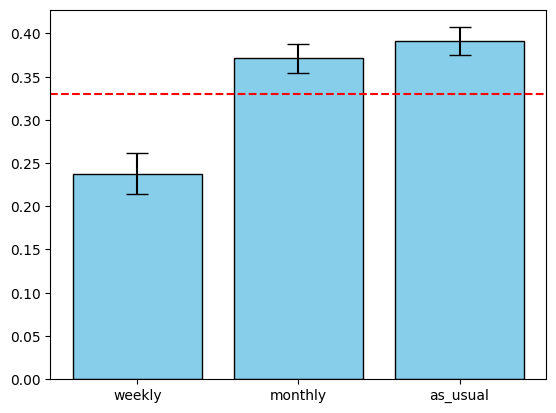

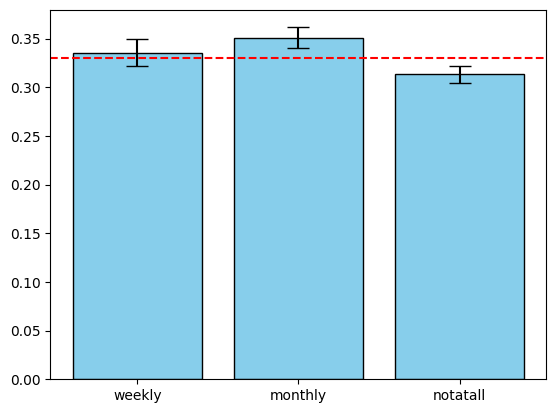

In [28]:
import matplotlib.pyplot as plt 
import random as rd
from time import time
import numpy as np

rd.seed(time())
res_dfs = [pan.DataFrame(r,columns=["id","action","motivation"]) for r in results]

feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}

mean_distributions = []

assigned_per_action = []

for scenario in range(2):
    feedbacks = dfs[scenario].merge(
        res_dfs[scenario],
        left_on=["n", "action_name"],
        right_on=["id", "action"],
        how="inner"
    )[["id","action","feedback"]] 
    feedbacks["feedback"] = feedbacks["feedback"].map(feedback_map) 
    
    assigned_per_action.append(feedbacks.groupby("action")["action"].count())
    #Let's repeat those random dropouts 50 times to generate interesting average values
    distributions = {ac:[] for ac in action_names[scenario]}

    for _ in range(50):
        random_dropouts = [rd.random() for _ in range(len(feedbacks))]
        remaining = feedbacks[feedbacks["feedback"]>random_dropouts]
        distribution = remaining.groupby("action")["action"].count().div(len(remaining))
        for ac in action_names[scenario]:
            distributions[ac].append(distribution[ac])

    mean_distributions.append({ac : (np.mean(distributions[ac]),np.std(distributions[ac])) for ac in action_names[scenario]})

print(mean_distributions)

for scenario in range(len(mean_distributions)):

    plt.bar(action_names[scenario], 
            [a for (a,b) in mean_distributions[scenario].values()],
            yerr = [b for (a,b) in mean_distributions[scenario].values()],
            capsize=8, color='skyblue', edgecolor='black')
    plt.axhline(y=0.33, color='red', linestyle='--', linewidth=1.5, label='Target distribution')
    plt.show()


Now let's compare dropouts with other methods, first we have to simulate those other methods on the participants

In [ ]:
methods = ["optimac","random","roundrobin","highestrank"]
other_methods = ["random","roundrobin","highestrank"]

def random_assignment(participant,scenario):
    selected = action_names[scenario][rd.randrange(3)]
    return (participant["id"],selected,participant["motivations"][selected])

def roundrobin_assignment(n,participant,scenario):
    selected = action_names[scenario][n%3]
    return (participant["id"],selected,participant["motivations"][selected])

def highestrank_assignment(participant,scenario):
    max_motiv = -float("inf")
    highest_ranked_action = ""
    motivs = list(participant["motivations"].items() )
    rd.shuffle(motivs)
    for (k,v) in motivs:
        if v > max_motiv:
            highest_ranked_action = k
    return(participant["id"],highest_ranked_action,participant["motivations"][highest_ranked_action])


def compute_stats(scenario):
    #first let's compute the assignments : 
    assignments = {}


    assignments["random"] = pan.DataFrame([random_assignment(p,scenario) for p in participants[scenario]],columns=["id","action","motivation"])
    assignments["roundrobin"] = pan.DataFrame([roundrobin_assignment(idx,p,scenario) for idx,p in enumerate(participants[scenario])],columns=["id","action","motivation"])
    assignments["highestrank"] = pan.DataFrame([highestrank_assignment(p,scenario) for p in participants[scenario]],columns=["id","action","motivation"])


    stats_before = {m:(assignments[m].groupby("action")["action"].count().values,[0,0,0]) for m in other_methods}
    #in the case of optimac we reuse the data computed above
    stats_before["optimac"] =  [assigned_per_action[scenario].values,[0,0,0]]


    feedbacks = {}


    for m in other_methods:
        feedbacks[m] = dfs[scenario].merge(assignments[m],left_on=["n", "action_name"], right_on=["id", "action"], how="inner")[["id","action","feedback"]]
        feedbacks[m]["feedback"] = feedbacks[m]["feedback"].map(feedback_map) 
    for _ in range(50):
        random_dropouts = [rd.random() for _ in range(len(feedbacks["random"]))]
        remaining_parts = {m:feedbacks[m][feedbacks[m]["feedback"]>random_dropouts]for m in other_methods}
        stats_after.append({m:(remaining_parts[m].groupby("action")["action"].count().values) for m in other_methods})

compute_stats(0)



Now let's analyze the results from these simulations.

In [ ]:
methods = ["optimac","random","roundrobin","highestrank"]

for scenario in range(2):
# --- Plotting ---
    categories = action_names[scenario]
    x = np.arange(len(categories))
    total_width = 0.8
    n_methods = len(methods)
    bar_width = total_width / (2 * n_methods)  # Each method has 2 bars: before & after

    fig, ax = plt.subplots(figsize=(14, 7))

    for idx, method in enumerate(methods):
        mean_before, std_before = stats_before[method]
        mean_after, std_after = stats_after[method]

        offsets = x + (idx - n_methods / 2) * 2 * bar_width + bar_width / 2
        color = method_colors[method]

        # Before bars
        ax.bar(offsets - bar_width / 2, mean_before, bar_width, yerr=std_before,
            label=f'{method} - Before', capsize=4, color=color, hatch=hatch_before, alpha=0.8)

        # After bars
        ax.bar(offsets + bar_width / 2, mean_after, bar_width, yerr=std_after,
            label=f'{method} - After', capsize=4, color=color, hatch=hatch_after, alpha=0.8)

    # --- Formatting with larger fonts ---
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, fontsize=18)
    ax.set_ylabel("Average Number of Participant", fontsize=16)
    ax.set_title("Comparison of Average Number of Participants Before and After Drop out Simulation\n(Mean ± Std)", fontsize=18)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Legend with bigger font
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=14)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
